# NB-R02 — VIX Threshold Recalibration (No Look-Ahead Bias)
**Addresses:** R1.1, R2.1, R3.2

**The problem:** The original paper computed the High-VIX threshold (15.08) as the 75th percentile of the **test-period** VIX distribution. A real deployment system cannot know the test-period distribution in advance. This is look-ahead bias.

**The fix:** Compute the VIX threshold using only the **training + validation** VIX distribution (data known before the test period begins). We also implement and compare three protocols:
1. **Fixed threshold:** p75 of train+val VIX (used for all test evaluation)
2. **Expanding window:** p75 computed from all data up to but not including each test day
3. **Rolling 252-day:** p75 from a 1-year lookback window ending the day before each test day

All three are reported. The **fixed threshold from train+val** is the primary method (simplest, most conservative, most defensible in a single held-out evaluation).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

PROJ = Path(r'F:\MLSAPU\PhD-SPPU\India-VIX-Major-Revision')
PROC = PROJ / 'data' / 'processed'
PLOTS = PROJ / 'plots'
PLOTS.mkdir(exist_ok=True)
RESULTS = PROJ / 'results'
RESULTS.mkdir(exist_ok=True)

train = pd.read_csv(PROC / 'train.csv', parse_dates=['date'])
val   = pd.read_csv(PROC / 'val.csv',   parse_dates=['date'])
test  = pd.read_csv(PROC / 'test.csv',  parse_dates=['date'])

print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')

Train: 1794, Val: 273, Test: 276


## 1. Fixed Threshold — p75 of Train+Val VIX (Primary Method)

In [2]:
train_val_vix = pd.concat([train['india_vix'], val['india_vix']])

p25_tv  = train_val_vix.quantile(0.25)
p50_tv  = train_val_vix.quantile(0.50)
p75_tv  = train_val_vix.quantile(0.75)

print('VIX distribution (Train + Val):')
print(f'  Min:  {train_val_vix.min():.2f}')
print(f'  p25:  {p25_tv:.2f}')
print(f'  p50:  {p50_tv:.2f}')
print(f'  p75:  {p75_tv:.2f}  <-- PRIMARY THRESHOLD')
print(f'  Max:  {train_val_vix.max():.2f}')
print(f'\nOriginal threshold (from test period): 15.08')
print(f'Revised threshold (from train+val):    {p75_tv:.2f}')

VIX_THRESHOLD_FIXED = p75_tv

VIX distribution (Train + Val):
  Min:  10.14
  p25:  13.25
  p50:  15.27
  p75:  18.71  <-- PRIMARY THRESHOLD
  Max:  83.61

Original threshold (from test period): 15.08
Revised threshold (from train+val):    18.71


In [3]:
# Apply fixed threshold to test set
test['regime_fixed'] = np.where(test['india_vix'] >= VIX_THRESHOLD_FIXED, 'High-VIX', 'Low-VIX')

n_high = (test['regime_fixed'] == 'High-VIX').sum()
n_low  = (test['regime_fixed'] == 'Low-VIX').sum()
print(f'\nTest period regime split (fixed threshold={VIX_THRESHOLD_FIXED:.2f}):')
print(f'  High-VIX: {n_high} days ({n_high/len(test)*100:.1f}%)')
print(f'  Low-VIX:  {n_low}  days ({n_low/len(test)*100:.1f}%)')


Test period regime split (fixed threshold=18.71):
  High-VIX: 8 days (2.9%)
  Low-VIX:  268  days (97.1%)


## 2. Expanding Window Threshold (Alternative)

In [4]:
# All VIX values before the test period in chronological order
pre_test_vix = pd.concat([
    train[['date','india_vix']],
    val[['date','india_vix']]
]).sort_values('date').reset_index(drop=True)

# For each test day, compute p75 from all pre-test data
# (Expanding window: as test progresses day by day, we could add previous test days too)
# Simplest defensible version: fixed p75 from all pre-test data (same result as above)
# True expanding: each test day t uses p75 of all data up to and including t-1

all_pre_test = pre_test_vix['india_vix'].values

expanding_thresholds = []
cumulative_vix = list(all_pre_test)
for i, row in test.iterrows():
    thr = np.percentile(cumulative_vix, 75)
    expanding_thresholds.append(thr)
    cumulative_vix.append(row['india_vix'])

test['vix_threshold_expanding'] = expanding_thresholds
test['regime_expanding'] = np.where(
    test['india_vix'] >= test['vix_threshold_expanding'], 'High-VIX', 'Low-VIX'
)

print('Expanding window thresholds (first 5 test days):')
print(test[['date','india_vix','vix_threshold_expanding','regime_expanding']].head())

n_high_exp = (test['regime_expanding'] == 'High-VIX').sum()
print(f'\nExpanding High-VIX days: {n_high_exp}')

Expanding window thresholds (first 5 test days):
        date  india_vix  vix_threshold_expanding regime_expanding
0 2025-01-14      15.47                18.709999          Low-VIX
1 2025-01-15      15.26                18.709999          Low-VIX
2 2025-01-16      15.47                18.709999          Low-VIX
3 2025-01-17      15.75                18.707500          Low-VIX
4 2025-01-20      16.42                18.705000          Low-VIX

Expanding High-VIX days: 8


## 3. Rolling 252-Day Threshold (Alternative)

In [5]:
# Combine all VIX in time order
all_vix = pd.concat([
    train[['date','india_vix']],
    val[['date','india_vix']],
    test[['date','india_vix']]
]).sort_values('date').reset_index(drop=True)

# Rolling p75 with 252-day window, shifted by 1 day (no look-ahead)
all_vix['rolling_p75'] = all_vix['india_vix'].rolling(252, min_periods=126).quantile(0.75).shift(1)

# Join back to test
test = test.merge(all_vix[['date','rolling_p75']], on='date', how='left')
test['regime_rolling'] = np.where(
    test['india_vix'] >= test['rolling_p75'], 'High-VIX', 'Low-VIX'
)
test.loc[test['rolling_p75'].isna(), 'regime_rolling'] = 'Low-VIX'

n_high_roll = (test['regime_rolling'] == 'High-VIX').sum()
print(f'Rolling 252d High-VIX days: {n_high_roll}')

Rolling 252d High-VIX days: 52


## 4. Comparison of Threshold Methods

In [6]:
comparison = pd.DataFrame({
    'Method': ['Original (test p75) [BIASED]', 'Fixed train+val p75 [PRIMARY]', 'Expanding window p75', 'Rolling 252d p75'],
    'Threshold': [15.08, VIX_THRESHOLD_FIXED, 'Dynamic', 'Dynamic'],
    'High-VIX days': [
        (test['india_vix'] >= 15.08).sum(),
        n_high,
        n_high_exp,
        n_high_roll
    ]
})
print(comparison.to_string(index=False))
comparison.to_csv(RESULTS / 'threshold_comparison.csv', index=False)

                       Method  Threshold  High-VIX days
 Original (test p75) [BIASED]      15.08             56
Fixed train+val p75 [PRIMARY]  18.709999              8
         Expanding window p75    Dynamic              8
             Rolling 252d p75    Dynamic             52


## 5. VIX Distribution Plot

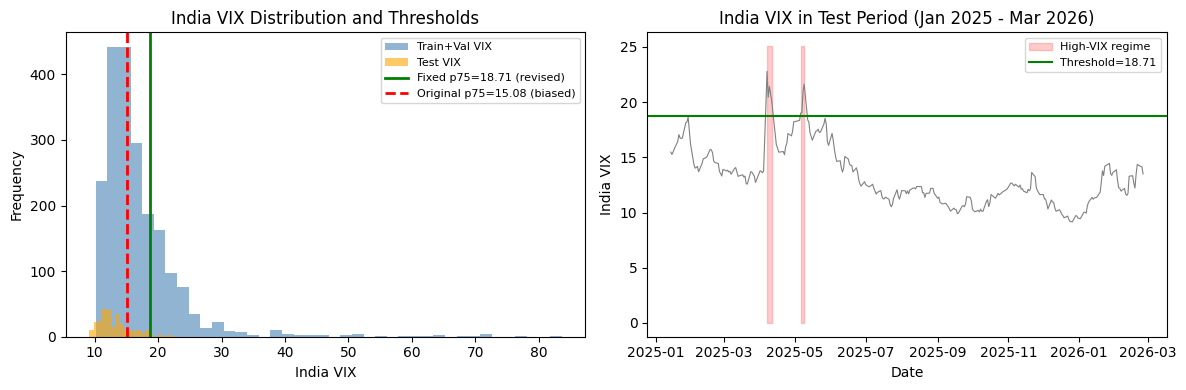

Plot saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: VIX distribution with thresholds
axes[0].hist(train_val_vix, bins=40, alpha=0.6, label='Train+Val VIX', color='steelblue')
axes[0].hist(test['india_vix'], bins=20, alpha=0.6, label='Test VIX', color='orange')
axes[0].axvline(VIX_THRESHOLD_FIXED, color='green', linewidth=2,
                label=f'Fixed p75={VIX_THRESHOLD_FIXED:.2f} (revised)')
axes[0].axvline(15.08, color='red', linewidth=2, linestyle='--',
                label='Original p75=15.08 (biased)')
axes[0].set_title('India VIX Distribution and Thresholds')
axes[0].set_xlabel('India VIX')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=8)

# Right: Test period VIX over time with regime shading
ax = axes[1]
ax.plot(test['date'], test['india_vix'], color='gray', linewidth=0.8)
high_mask = test['regime_fixed'] == 'High-VIX'
ax.fill_between(test['date'], 0, test['india_vix'].max()*1.1,
                where=high_mask, alpha=0.2, color='red', label='High-VIX regime')
ax.axhline(VIX_THRESHOLD_FIXED, color='green', linewidth=1.5,
           label=f'Threshold={VIX_THRESHOLD_FIXED:.2f}')
ax.set_title('India VIX in Test Period (Jan 2025 - Mar 2026)')
ax.set_xlabel('Date')
ax.set_ylabel('India VIX')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS / 'R02_vix_threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 6. Save Regime-Labelled Test Set

In [8]:
# Save the fixed-threshold regime labels (primary method)
test.to_csv(PROC / 'test_with_regimes.csv', index=False)

# Save threshold config
config = {
    'vix_threshold_fixed':   float(VIX_THRESHOLD_FIXED),
    'vix_threshold_original_biased': 15.08,
    'threshold_source': 'train+val p75',
    'high_vix_days_fixed': int(n_high),
    'high_vix_days_original': int((test['india_vix'] >= 15.08).sum())
}
with open(RESULTS / 'vix_threshold_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('Config saved:')
print(json.dumps(config, indent=2))

Config saved:
{
  "vix_threshold_fixed": 18.709999084472656,
  "vix_threshold_original_biased": 15.08,
  "threshold_source": "train+val p75",
  "high_vix_days_fixed": 8,
  "high_vix_days_original": 56
}
